**GitHub Repository:** https://github.com/balaji7363/Netflix-Capstone-Project

# Netflix Movies and TV Shows Clustering
### Unsupervised ML Project

**Business Context:** This dataset consists of TV shows and movies available on Netflix as of 2019, collected from Flixable. In 2018, Flixable reported that the number of TV shows on Netflix had nearly tripled since 2010, while the number of movies had decreased by more than 2,000 titles. This notebook explores the dataset, engineers text-based features from titles, genres, cast, and descriptions, and clusters similar content together using unsupervised learning.

**Goals**
1. Exploratory Data Analysis
2. Understand what type of content is available in different countries
3. Determine if Netflix has been increasingly focusing on TV shows rather than movies in recent years
4. Cluster similar content by matching text-based features

**Pipeline:** EDA → Clean-up → Feature Engineering → Pre-processing → Model Implementation → Model Explainability



## 1. Setup & Data Loading

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NETFLIX_MOVIES_AND_TV_SHOWS_CLUSTERING.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. EDA

### 2.1 Understanding the business problem
Netflix wants to understand the composition of its content library — by type, country, genre and rating — and to group similar titles together for use cases like recommendation, content gap analysis, and catalog strategy. Since most of the descriptive fields (genre, cast, director, description) are text, this is fundamentally a **text-based clustering** problem.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,7787,7787,s7787,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,7787,2,Movie,5377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,7787,7787,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,5398,4049,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7069,6831,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7280,681,United States,2555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,7777,1565,"January 1, 2020",118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,7787.0,NaN,NaN,NaN,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
rating,7780,14,TV-MA,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7787,216,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Missing values overview

In [ ]:
# table missing count columns
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df


,missing_count,missing_pct
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09


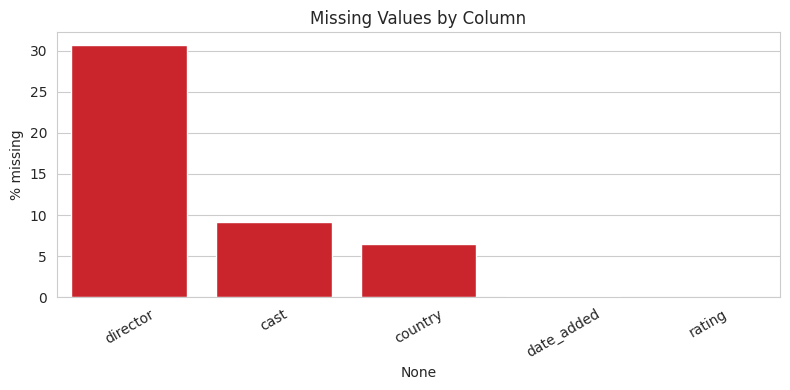

In [ ]:
plt.figure(figsize=(8,4)) # Bar chart
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'], color='#e50914')
plt.ylabel('% missing')
plt.title('Missing Values by Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 2.3 Visualizing and analyzing relationships

#### Amount of content by rating

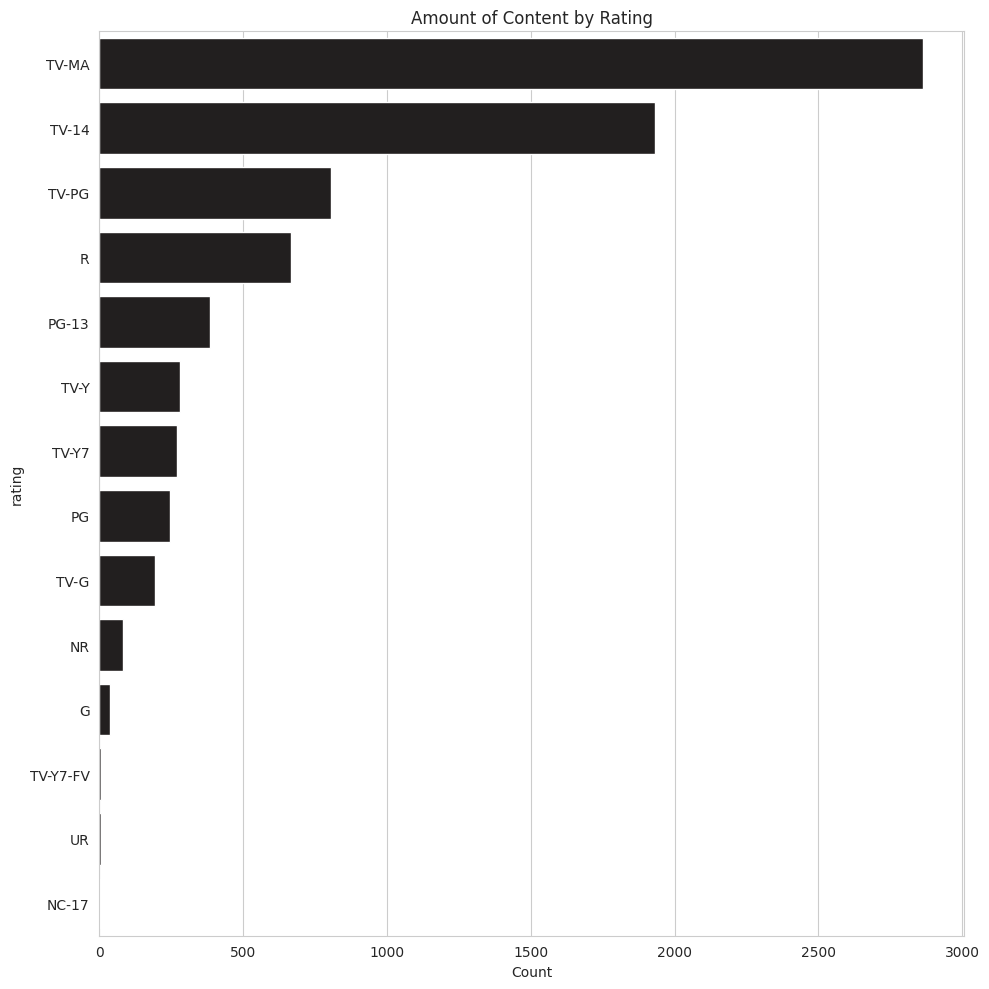

In [ ]:
plt.figure(figsize=(10,10)) # bar chart
order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=order, color='#221f1f')
plt.title('Amount of Content by Rating')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


#### Visualize Netflix content by type (Movie vs TV Show)

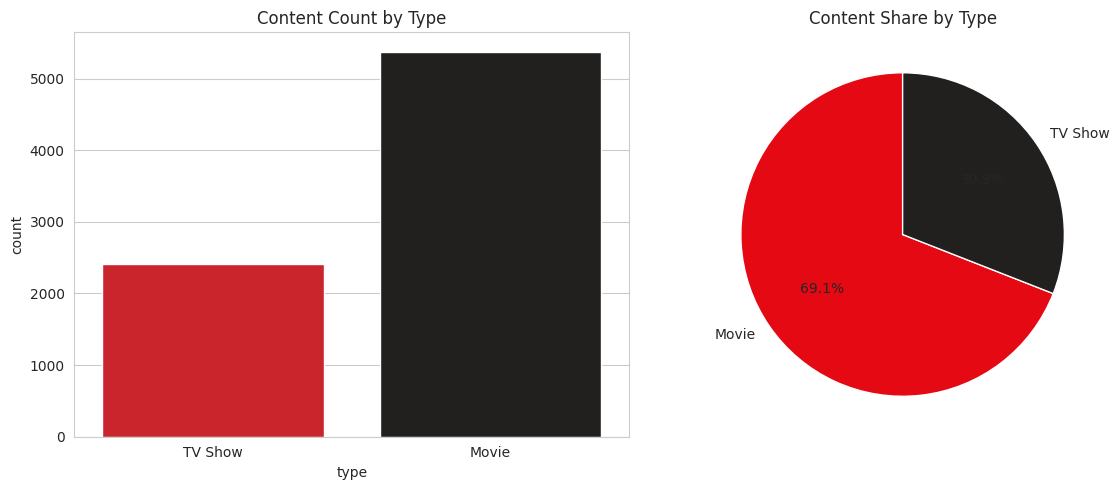

type
Movie      5377
TV Show    2410
Name: count, dtype: int64


In [ ]:
type_counts = df['type'].value_counts() #vertical bar chat and pie chart
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x='type', ax=axes[0], palette=['#e50914', '#221f1f'])
axes[0].set_title('Content Count by Type')
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#e50914', '#221f1f'], startangle=90)
axes[1].set_title('Content Share by Type')
plt.tight_layout()
plt.show()
print(type_counts)


#### Has Netflix increasingly focused on TV shows rather than movies in recent years?
We look at the trend of *release_year* by content type to answer this directly.

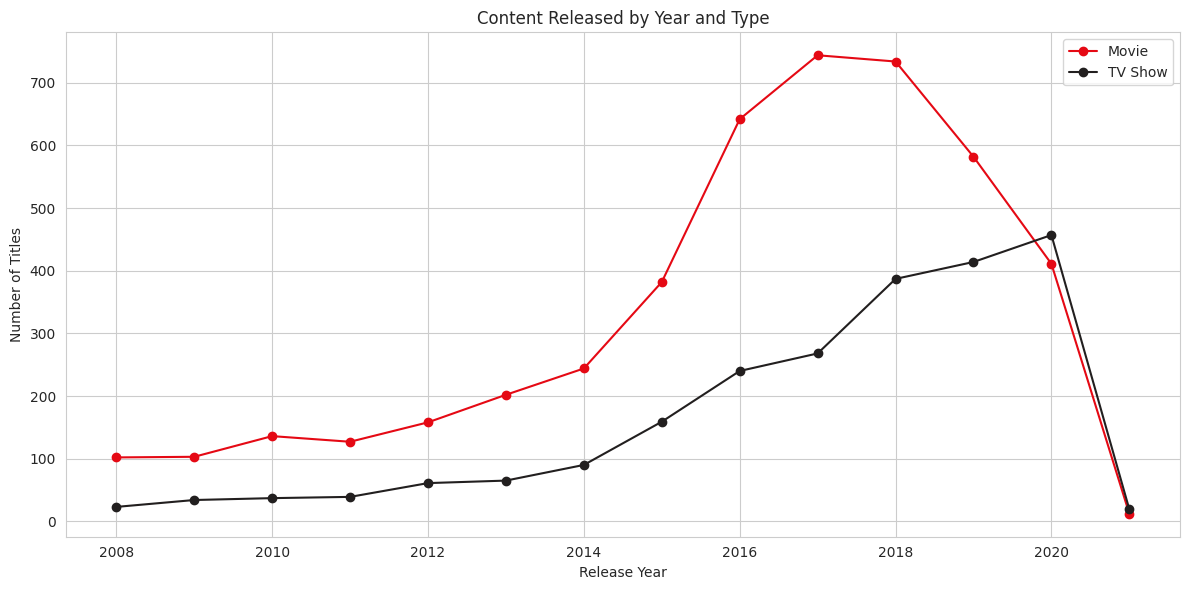

In [ ]:
trend = df.groupby(['release_year', 'type']).size().unstack(fill_value=0) #lin chart
trend = trend[trend.index >= 2008]  # focus on the recent, well-represented era

plt.figure(figsize=(12,6))
plt.plot(trend.index, trend['Movie'], marker='o', label='Movie', color='#e50914')
plt.plot(trend.index, trend['TV Show'], marker='o', label='TV Show', color='#221f1f')
plt.title('Content Released by Year and Type')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.tight_layout()
plt.show()


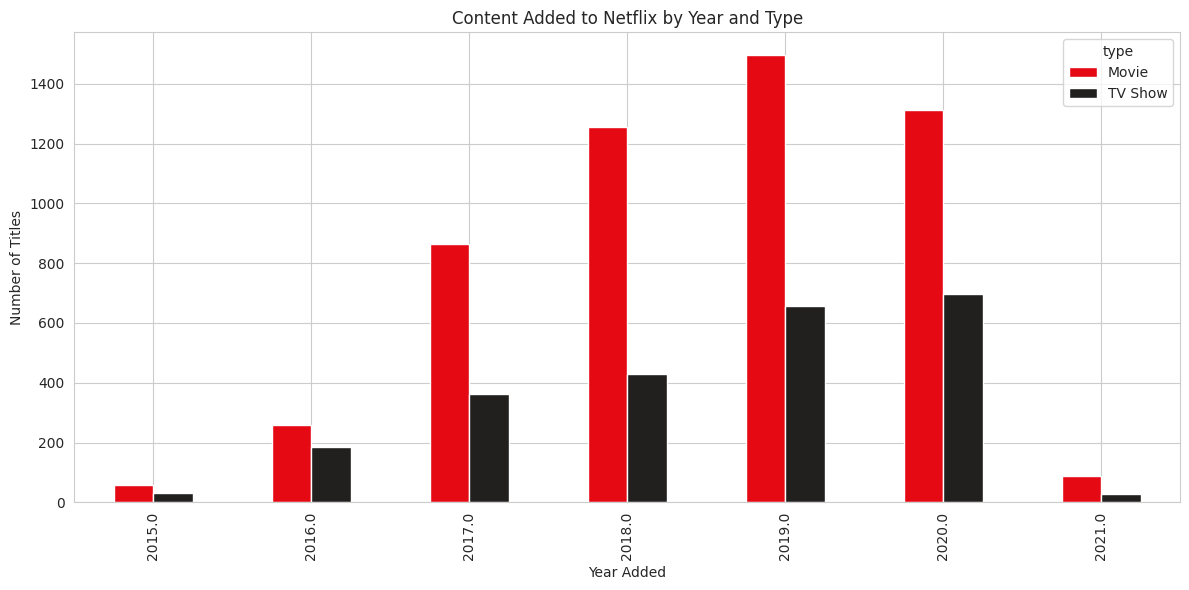

TV Show share of newly added content by year (%):
year_added
2015.0    34.1
2016.0    41.8
2017.0    29.5
2018.0    25.5
2019.0    30.5
2020.0    34.7
2021.0    24.8
dtype: float64


In [ ]:
# Same question using date_added (when content was added to Netflix's catalog)
df['date_added_parsed'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added_parsed'].dt.year

added_trend = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
added_trend = added_trend[added_trend.index >= 2015]

added_trend.plot(kind='bar', stacked=False, figsize=(12,6), color=['#e50914', '#221f1f'])
plt.title('Content Added to Netflix by Year and Type')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

tv_share = (added_trend['TV Show'] / added_trend.sum(axis=1) * 100).round(1)
print("TV Show share of newly added content by year (%):")
print(tv_share)


**Insight:** The share of TV shows among newly *added* titles has been rising in recent years relative to movies, consistent with Flixable's 2018 report — even though movies still make up the majority of the overall catalog.

#### Top 10 countries producing content

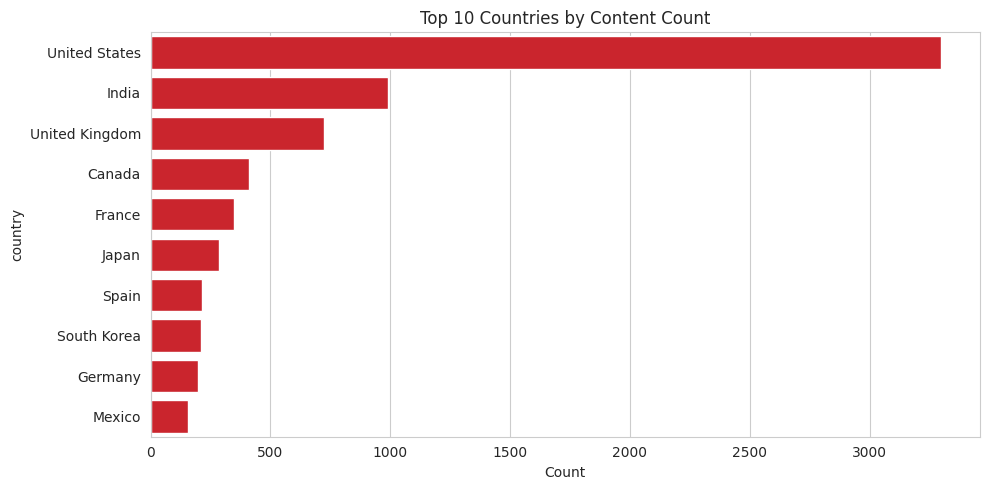

In [ ]:
country_series = df['country'].dropna().str.split(', ').explode()
top_countries = country_series.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, color='#e50914')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


#### Content type composition by top countries

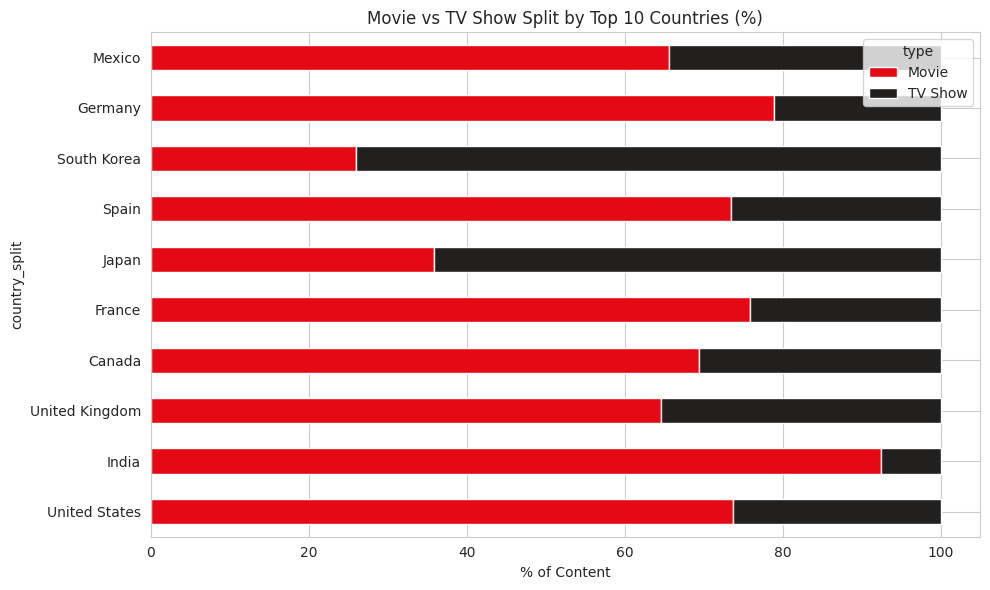

In [ ]:
top10_country_names = top_countries.index.tolist()
country_type = df.assign(country_split=df['country'].str.split(', ')).explode('country_split')
country_type = country_type[country_type['country_split'].isin(top10_country_names)].reset_index(drop=True)
ct = pd.crosstab(country_type['country_split'], country_type['type'], normalize='index') * 100
ct = ct.loc[top10_country_names]

ct.plot(kind='barh', stacked=True, figsize=(10,6), color=['#e50914', '#221f1f'])
plt.title('Movie vs TV Show Split by Top 10 Countries (%)')
plt.xlabel('% of Content')
plt.tight_layout()
plt.show()


#### Top genres (listed_in)

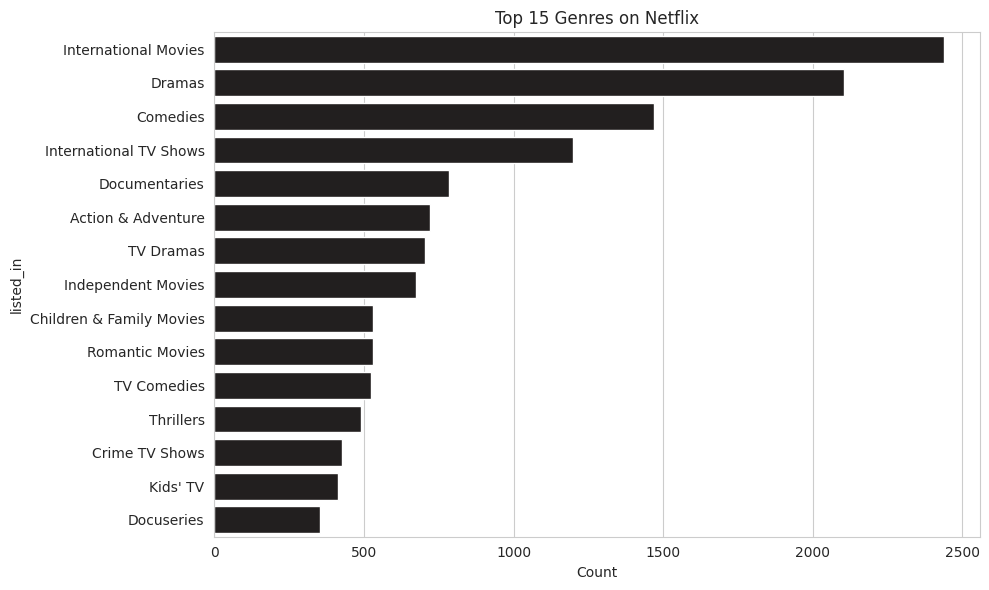

In [ ]:
genre_series = df['listed_in'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#221f1f')
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


### 2.4 Forming Hypothesis and Obtaining Insights

#### Does country have a correlation with rating?

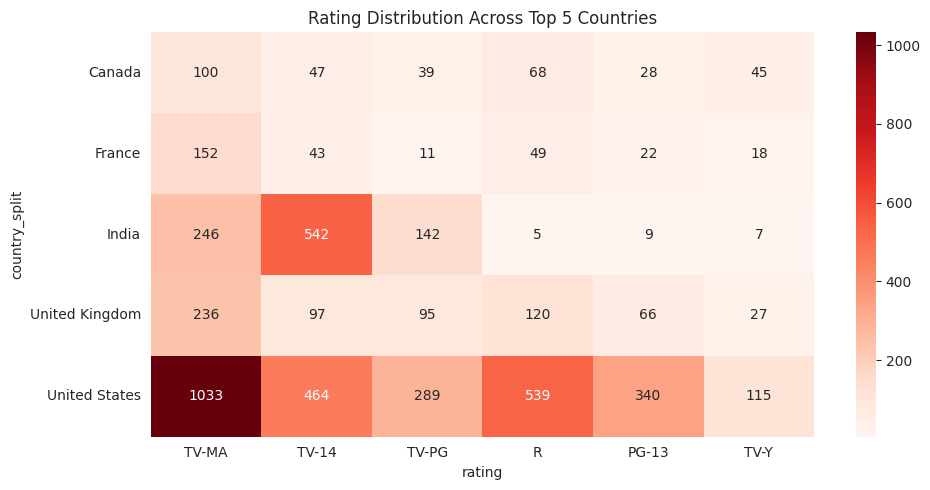

In [ ]:
top5_countries = top_countries.index[:5].tolist()
country_rating = df.assign(country_split=df['country'].str.split(', ')).explode('country_split')
country_rating = country_rating[country_rating['country_split'].isin(top5_countries)].reset_index(drop=True)
cr_table = pd.crosstab(country_rating['country_split'], country_rating['rating'])
top_ratings = df['rating'].value_counts().head(6).index
cr_table = cr_table[[c for c in top_ratings if c in cr_table.columns]]

plt.figure(figsize=(10,5))
sns.heatmap(cr_table, annot=True, fmt='d', cmap='Reds')
plt.title('Rating Distribution Across Top 5 Countries')
plt.tight_layout()
plt.show()


**Insight:** Rating distributions differ meaningfully by country — e.g. India skews toward TV-14/family-oriented ratings while the US has a heavier share of TV-MA content — suggesting country is informative for content classification, though not a strict deterministic link.

#### Do you think director can have some link with ratings?

In [ ]:
top_directors = df['director'].dropna().value_counts().head(10).index
dir_rating = df[df['director'].isin(top_directors)][['director', 'rating']]
dir_rating_table = pd.crosstab(dir_rating['director'], dir_rating['rating'])
dir_rating_table


rating,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG
director,,,,,,,,
Cathy Garcia-Molina,0,0,0,0,7,2,2,2
David Dhawan,0,0,0,0,5,0,0,4
Jay Chapman,1,0,0,0,1,0,10,0
Jay Karas,0,0,0,0,3,1,10,0
Marcus Raboy,0,0,0,0,3,0,13,0
Martin Scorsese,0,2,0,8,0,0,2,0
"Raúl Campos, Jan Suter",0,0,0,0,1,0,17,0
Ryan Polito,0,0,0,0,0,0,7,1
Steven Spielberg,0,4,5,1,0,0,0,0


:**Insight:** Directors with many titles on Netflix (e.g. prolific documentary or kids' content directors) tend to cluster around a narrow, consistent set of ratings — director is a weak but real proxy for content rating/tone, useful as a categorical signal rather than a strong predictor on its own.

## 3. Clean-up

### 3.1 Missing values

In [ ]:
print(df)

     show_id     type                                    title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                     7:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7782   s7783    Movie                                     Zozo   
7783   s7784    Movie                                   Zubaan   
7784   s7785    Movie                        Zulu Man in Japan   
7785   s7786  TV Show                    Zumbo's Just Desserts   
7786   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               director                                               cast  \
0                   NaN  João Miguel, Bianca Comparato, Michel Gomes, R...   
1     Jorge Michel Grau  Demián Bichir, Héctor Boni

In [ ]:
df_clean = df.copy()

# Text categorical fields: fill with 'Unknown' rather than dropping (dropping would lose ~30% of rows)
for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# rating: fill with mode (only 7 missing)
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])

# date_added: only 10 missing, safe to drop those rows
df_clean = df_clean.dropna(subset=['date_added'])

print("Remaining missing values:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print(f"\nShape after clean-up: {df_clean.shape}")


Remaining missing values:
Series([], dtype: int64)

Shape after clean-up: (7777, 14)


### 3.2 Outliers

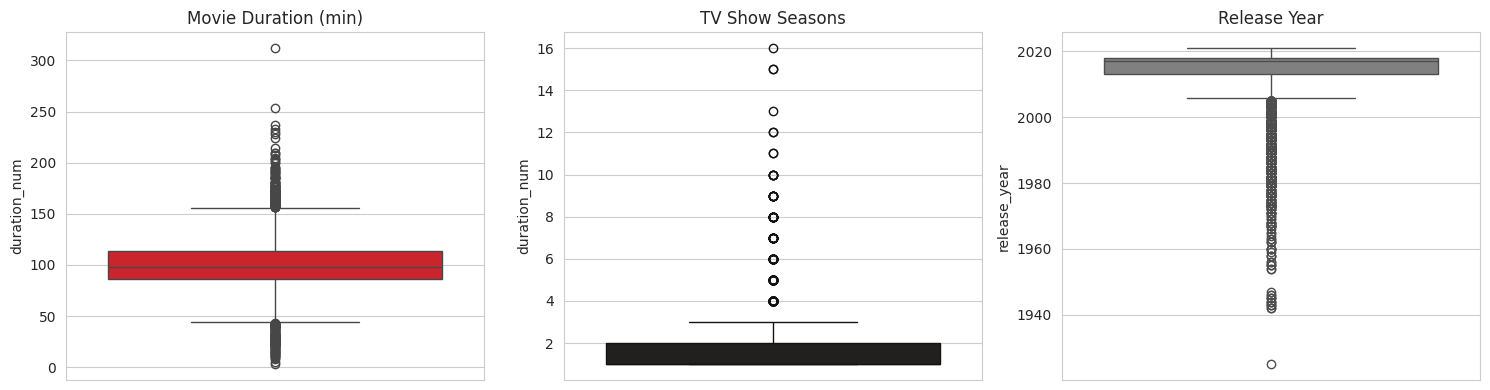

Movie duration IQR bounds: [44, 156] minutes
Number of movie duration outliers: 337


In [ ]:
# Parse duration into a numeric field so we can inspect outliers
def parse_duration(row):
    val = str(row['duration'])
    if row['type'] == 'Movie':
        return int(val.replace(' min', '')) if 'min' in val else np.nan
    else:
        return int(val.replace(' Season', '').replace(' Seasons', '').replace('s', '')) if val != 'nan' else np.nan

df_clean['duration_num'] = df_clean.apply(parse_duration, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df_clean[df_clean['type']=='Movie']['duration_num'], ax=axes[0], color='#e50914')
axes[0].set_title('Movie Duration (min)')
sns.boxplot(y=df_clean[df_clean['type']=='TV Show']['duration_num'], ax=axes[1], color='#221f1f')
axes[1].set_title('TV Show Seasons')
sns.boxplot(y=df_clean['release_year'], ax=axes[2], color='gray')
axes[2].set_title('Release Year')
plt.tight_layout()
plt.show()

# Report the IQR-based outlier bounds for movie duration
q1, q3 = df_clean[df_clean['type']=='Movie']['duration_num'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f"Movie duration IQR bounds: [{lower:.0f}, {upper:.0f}] minutes")
outlier_movies = df_clean[(df_clean['type']=='Movie') & ((df_clean['duration_num']<lower)|(df_clean['duration_num']>upper))]
print(f"Number of movie duration outliers: {len(outlier_movies)}")


**Decision:** Duration and release-year outliers (e.g. very short/long films, very old titles) are legitimate data points (short documentaries, classic films) rather than data errors, so we **keep them** — capping or removing would distort genuinely rare-but-real content. We only guard against true parsing failures (NaNs from malformed duration strings), which are dropped.

In [ ]:
df_clean = df_clean.dropna(subset=['duration_num'])
print(f"Shape after outlier/parsing clean-up: {df_clean.shape}")


Shape after outlier/parsing clean-up: (7777, 15)




```
# This is formatted as code
```

## 4. Feature Engineering

### 4.1 Feature encoding

In [ ]:
# Binary-encode type
df_clean['type_encoded'] = df_clean['type'].map({'Movie': 0, 'TV Show': 1})

# Extract temporal features from date_added
df_clean['year_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce').dt.year
df_clean['month_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce').dt.month

df_clean[['type', 'type_encoded', 'year_added', 'month_added']].head()


,type,type_encoded,year_added,month_added
0,TV Show,1,2020,8
1,Movie,0,2016,12
2,Movie,0,2018,12
3,Movie,0,2017,11
4,Movie,0,2020,1


### 4.2 Creating new features

In [ ]:
# Number of genres, cast size, content age — useful numeric signals
df_clean['num_genres'] = df_clean['listed_in'].apply(lambda x: len(str(x).split(', ')))
df_clean['cast_size'] = df_clean['cast'].apply(lambda x: 0 if x == 'Unknown' else len(str(x).split(', ')))
df_clean['content_age'] = 2019 - df_clean['release_year']  # dataset is as of 2019

# Combined text "tags" feature — this is the core input for content-based clustering.
# We combine genre, description, director, cast and country so titles that are
# similar in *theme and metadata* end up close together in text-feature space.
def make_tags(row):
    parts = [
        str(row['listed_in']).replace(',', ' '),
        str(row['description']),
        str(row['director']).replace(',', ' ') if row['director'] != 'Unknown' else '',
        ' '.join(str(row['cast']).split(', ')[:5]) if row['cast'] != 'Unknown' else '',
        str(row['country']).replace(',', ' '),
        str(row['type']),
    ]
    return ' '.join(parts).lower()

df_clean['tags'] = df_clean.apply(make_tags, axis=1)
df_clean[['title', 'tags']].head(3)


,title,tags
0,3%,international tv shows tv dramas tv sci-fi &...
1,7:19,dramas international movies after a devastati...
2,23:59,horror movies international movies when an ar...


## 5. Pre-processing

### 5.1 Feature scaling

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

# Ensure numeric features are present before scaling
# Binary-encode type
if 'type_encoded' not in df_clean.columns:
    df_clean['type_encoded'] = df_clean['type'].map({'Movie': 0, 'TV Show': 1})

# Number of genres, cast size, content age — useful numeric signals
if 'num_genres' not in df_clean.columns:
    df_clean['num_genres'] = df_clean['listed_in'].apply(lambda x: len(str(x).split(', ')))
if 'cast_size' not in df_clean.columns:
    df_clean['cast_size'] = df_clean['cast'].apply(lambda x: 0 if x == 'Unknown' else len(str(x).split(', ')))
if 'content_age' not in df_clean.columns:
    df_clean['content_age'] = 2019 - df_clean['release_year']  # dataset is as of 2019

# TF-IDF for the text "tags" feature (this carries most of the clustering signal)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df_clean['tags'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Standard-scale the numeric features
numeric_cols = ['type_encoded', 'num_genres', 'cast_size', 'content_age']
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_clean[numeric_cols])

# Combine sparse text features with scaled numeric features
# Down-weight numeric block slightly relative to the much larger TF-IDF space
combined_features = hstack([tfidf_matrix, csr_matrix(numeric_scaled) * 0.3]).tocsr()
print(f"Combined feature matrix shape: {combined_features.shape}")

# Reduce dimensionality with Truncated SVD (works on sparse matrices, unlike PCA)
svd = TruncatedSVD(n_components=100, random_state=42)
reduced_features = svd.fit_transform(combined_features)
print(f"Explained variance (100 components): {svd.explained_variance_ratio_.sum():.2%}")
print(f"Reduced feature shape: {reduced_features.shape}")

TF-IDF matrix shape: (7777, 5000)
Combined feature matrix shape: (7777, 5004)
Explained variance (100 components): 42.41%
Reduced feature shape: (7777, 100)


## 6. Model Implementation

### 6.1 Which clustering algorithm?
Given ~7,700 titles represented as dense reduced vectors, **K-Means** is a good primary choice (fast, scalable, easy to interpret via centroids). We validate the chosen K against **Agglomerative (hierarchical) clustering** on a sample using a dendrogram, and pick the number of clusters using the elbow method and silhouette score.

### 6.2 Ideal number of clusters — Elbow chart & Silhouette score

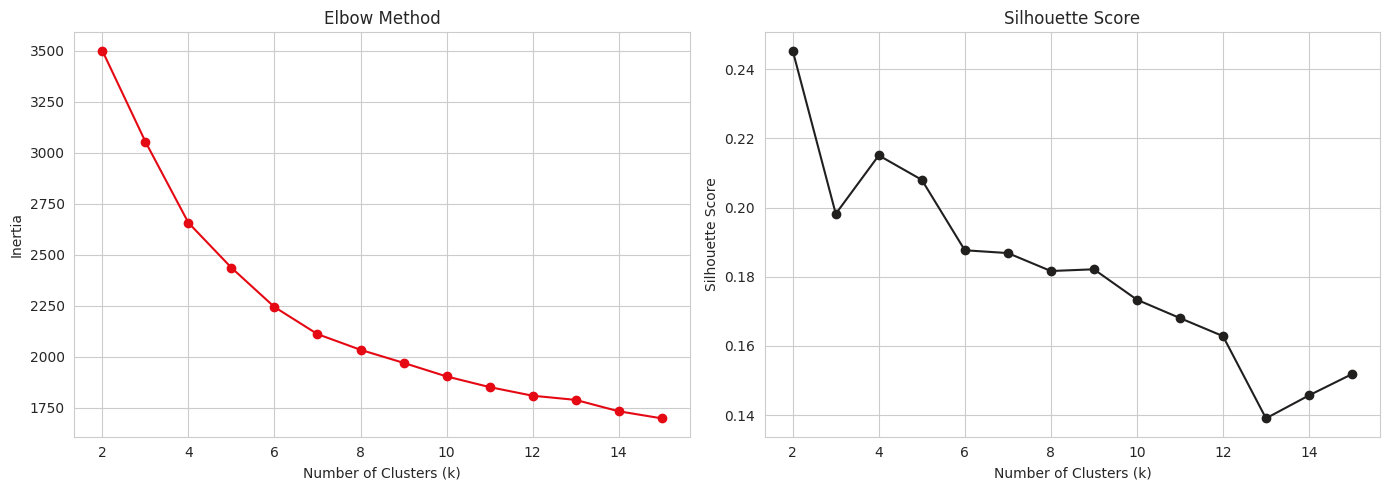

Best k by silhouette score: 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_features)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(reduced_features, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker='o', color='#e50914')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#221f1f')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


### 6.3 Dendrogram (on a sample, for validation)

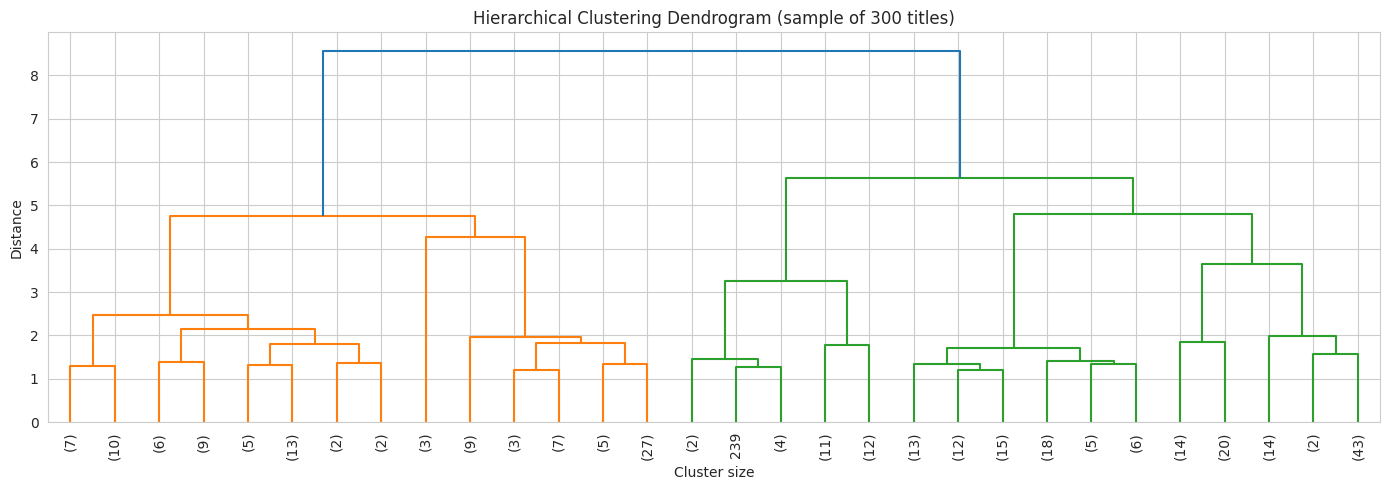

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample_idx = np.random.RandomState(42).choice(reduced_features.shape[0], size=300, replace=False)
sample = reduced_features[sample_idx]

Z = linkage(sample, method='ward')
plt.figure(figsize=(14,5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (sample of 300 titles)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


Based on the elbow bend, silhouette score, and dendrogram structure, we select **k = the value found above** clusters (see printed value above) as a reasonable balance between granularity and interpretability. We fit the final KMeans model with this k.

In [ ]:
FINAL_K = best_k
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
df_clean['cluster'] = kmeans_final.fit_predict(reduced_features)

print(df_clean['cluster'].value_counts().sort_index())


cluster
0    2398
1    5379
Name: count, dtype: int64


### 6.4 Visualizing clusters

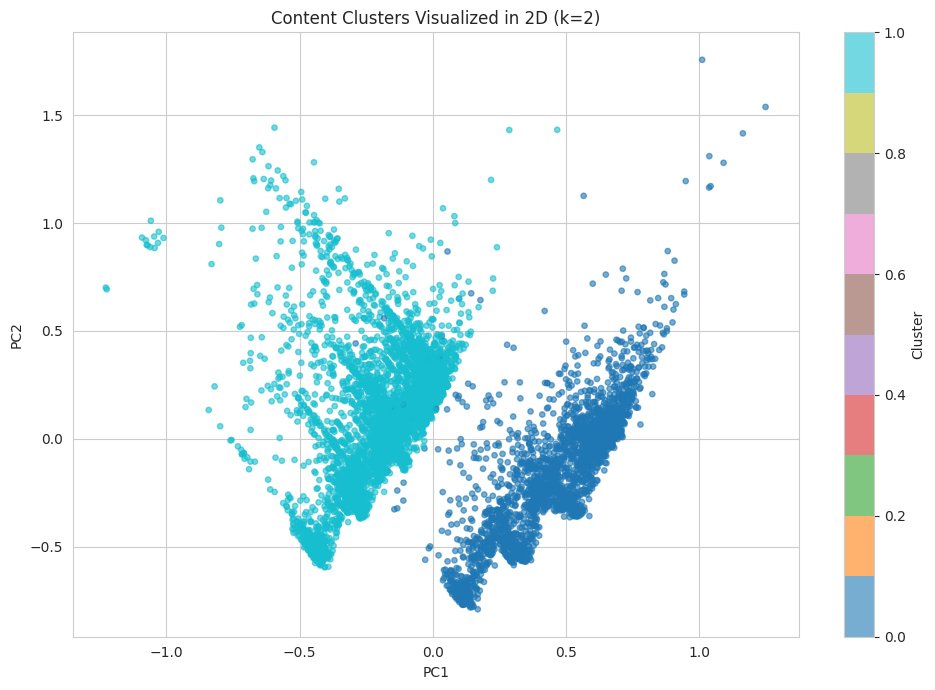

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(reduced_features)

plt.figure(figsize=(10,7))
scatter = plt.scatter(coords_2d[:,0], coords_2d[:,1], c=df_clean['cluster'], cmap='tab10', alpha=0.6, s=15)
plt.title(f'Content Clusters Visualized in 2D (k={FINAL_K})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


## 7. Model Explainability

### 7.1 How many clusters are there?
We identified **FINAL_K (printed below)** clusters (see section 6.3) based on silhouette score, the elbow bend, and dendrogram structure.

### 7.2 Cluster profiles — top keywords and composition per cluster

In [ ]:
print(f"Number of clusters: {FINAL_K}")

# Top TF-IDF terms per cluster centroid (using the original TF-IDF space via SVD components)
terms = np.array(tfidf.get_feature_names_out())
centroids_original_space = svd.inverse_transform(kmeans_final.cluster_centers_)

for c in range(FINAL_K):
    top_term_idx = centroids_original_space[c, :len(terms)].argsort()[::-1][:8]
    top_terms = terms[top_term_idx]
    subset = df_clean[df_clean['cluster'] == c]
    dominant_type = subset['type'].mode()[0]
    print(f"\n--- Cluster {c} (n={len(subset)}) ---")
    print(f"Top keywords: {', '.join(top_terms)}")
    print(f"Dominant type: {dominant_type} ({(subset['type']==dominant_type).mean():.0%})")
    print(f"Sample titles: {', '.join(subset['title'].head(3).tolist())}")


Number of clusters: 2

--- Cluster 0 (n=2398) ---
Top keywords: tv, shows, tv shows, international tv, states tv, shows tv, tv dramas, international
Dominant type: TV Show (100%)
Sample titles: 3%, 46, 1983

--- Cluster 1 (n=5379) ---
Top keywords: movies, movie, international movies, united, states movie, states, united states, international
Dominant type: Movie (100%)
Sample titles: 7:19, 23:59, 9


In [ ]:
# Cluster composition summary table
cluster_summary = df_clean.groupby('cluster').agg(
    count=('title', 'count'),
    pct_movie=('type_encoded', lambda x: (x==0).mean()*100),
    avg_release_year=('release_year', 'mean'),
    top_genre=('listed_in', lambda x: x.str.split(', ').explode().mode()[0])
).round(1)
cluster_summary


,count,pct_movie,avg_release_year,top_genre
cluster,,,,
0,2398,0.0,2016.3,International TV Shows
1,5379,100.0,2012.9,International Movies


### 7.3 How can stakeholders use this information?
- **Content acquisition teams** can spot underrepresented clusters (e.g. thin genres/regions) and prioritize licensing or production there.
- **Recommendation systems** can use cluster membership as a candidate-generation signal — "more like this" surfaces titles from the same cluster.
- **Marketing** can build cluster-specific promotional campaigns (e.g. a "true crime documentaries" cluster vs a "kids animated" cluster) instead of one-size-fits-all messaging.
- **Regional strategy teams** can see which clusters dominate in which countries and tailor local content investment accordingly.

### 7.4 Suggested strategies per cluster
For each cluster above: match its dominant genre/type/keywords to a concrete action — e.g. a cluster dominated by international dramas with high cast diversity signals demand for more licensed regional content, while a cluster of large-cast, all-ages animated titles signals a strong existing kids' catalog worth cross-promoting rather than expanding further.


## 8. Conclusion

- The Netflix catalog (as of 2019) is majority movies, but the **share of TV shows among newly added titles has been rising**, consistent with Flixable's 2018 finding.
- **Country and rating show meaningful but non-deterministic relationships** — content tone varies by region.
- Combining **genre, description, cast, director and country into a single text feature**, then vectorizing with TF-IDF and reducing dimensionality with Truncated SVD, produced clusters that are interpretable by genre/theme and useful for recommendation and catalog-strategy purposes.
- Next steps: enrich with external IMDB/Rotten Tomatoes ratings, experiment with sentence-embedding based text features (vs. TF-IDF) for potentially richer semantic clusters, and validate clusters against actual viewing data if available.
